# Predicción de congestión urbana

## Contexto del problema

El Ayuntamiento de una ciudad inteligente quiere anticipar episodios de congestión alta para apoyar decisiones operativas como ajustes semafóricos o avisos al ciudadano.

Para ello dispone de un dataset con variables de movilidad, contexto meteorológico, operación del transporte y otras señales auxiliares provenientes de sensores distribuidos por la ciudad.

El objetivo es construir un modelo que identifique casos de congestión alta y justificar las decisiones tomadas hasta llegar a un modelo robusto y adaptado a las necesidades operativas del Ayuntamiento.

## Librerias empleadas

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt # modulo especifico de gráficos
import seaborn as sns


## Exploración del caso de uso a estudiar

En esta sección se define el problema antes de tocar los datos. El objetivo es responder a las preguntas clave del caso de uso: qué se quiere predecir, quién usará el modelo y qué decisiones operativas permitirá tomar.

### Carga de datos

In [2]:
data = pd.read_csv('../data/dataset_smart_urban_mobility.csv')

print(f"Dimensiones dataset", data.shape)
print(f"Columnas del dataset",data.columns)
data.head()

Dimensiones dataset (720, 26)
Columnas del dataset Index(['id_registro', 'fecha', 'dia_semana_num', 'distrito', 'tipo_dia',
       'franja_horaria', 'id_sensor', 'temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales',
       'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'color_semaforo_dominante', 'campana_publicitaria',
       'porcentaje_hombres_zona', 'indice_congestion', 'congestion_alta'],
      dtype='str')


,id_registro,fecha,dia_semana_num,distrito,tipo_dia,franja_horaria,id_sensor,temperatura_c,humedad_relativa_pct,lluvia_mm,...,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,porcentaje_hombres_zona,indice_congestion,congestion_alta
0,1,2025-01-01,2,Centro,Laborable,Mañana,S-050,14.1,61.0,3.5,...,71.9,168.0,30.4,8.0,91.5,Verde,0,52.3,68.7,1
1,2,2025-01-01,2,Centro,Laborable,Mañana,S-028,12.6,54.0,12.9,...,70.4,73.0,24.9,8.0,97.6,Amarillo,0,52.8,62.2,1
2,3,2025-01-02,3,Este,Laborable,Tarde,S-003,22.0,39.0,2.8,...,75.8,136.0,42.4,9.0,100.2,Rojo,1,50.0,62.5,0
3,4,2025-01-02,3,Universidad,Laborable,Mañana,S-032,22.6,49.0,0.4,...,88.0,142.0,38.0,7.0,93.1,Amarillo,0,52.7,61.8,1
4,5,2025-01-03,4,Centro,Laborable,Tarde,S-001,19.3,44.0,3.6,...,79.1,141.0,21.0,12.0,96.2,Rojo,0,54.3,77.5,1


El dataset tiene 720 registros o observaciones y 26 variables o columnas

Para entender mejor qué representa cada fila del dataset, veamos un registro concreto:

In [3]:
data.head(1)

,id_registro,fecha,dia_semana_num,distrito,tipo_dia,franja_horaria,id_sensor,temperatura_c,humedad_relativa_pct,lluvia_mm,...,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,porcentaje_hombres_zona,indice_congestion,congestion_alta
0,1,2025-01-01,2,Centro,Laborable,Mañana,S-050,14.1,61.0,3.5,...,71.9,168.0,30.4,8.0,91.5,Verde,0,52.3,68.7,1


| Campo | Valor | Interpretación |
|---|---|---|
| `id_registro` | 1 | Primera fila del dataset |
| `fecha` | 2025-01-01 | 1 de enero de 2025 |
| `dia_semana_num` | 2 | Miércoles |
| `distrito` | Centro | Distrito Centro de la ciudad |
| `tipo_dia` | Laborable | Día entre semana |
| `franja_horaria` | Mañana | Registro tomado por la mañana |
| `id_sensor` | S-050 | Sensor número 50 |
| `temperatura_c` | 14.1°C | Temperatura fresca, típica de enero |
| `humedad_relativa_pct` | 61% | Humedad moderada |
| `lluvia_mm` | 3.5mm | Lluvia ligera |
| `ocupacion_bus_pct` | 71.9% | El autobús va bastante lleno |
| `plazas_aparcamiento_libres` | 168 | Bastantes plazas libres |
| `ocupacion_bici_pct` | 30.4% | Uso moderado de bicicletas |
| `numero_incidencias_app` | 8 | 8 incidencias reportadas por usuarios |
| `indice_ruido_historico` | 91.5 | Zona ruidosa |
| `color_semaforo_dominante` | Verde | Semáforos en verde predominantemente |
| `campana_publicitaria` | 0 | Sin campaña publicitaria activa |
| `porcentaje_hombres_zona` | 52.3% | Distribución casi equitativa por género |
| `indice_congestion` | 68.7 | Nivel de congestión moderado-alto |
| `congestion_alta` | **1** | **Hay congestión alta** |

Es decir, este registro representa una mañana de miércoles laborable en el distrito Centro, con lluvia ligera, autobuses bastante ocupados y 8 incidencias reportadas en la app. El resultado es congestión alta.

### Exploración de las variables 

El objetivo en esta sección es poder presentar una tabla con todas las variables y lo que significa cada una. Antes de nada, exploramos las distintas variables:

In [4]:
print(data['id_registro'].nunique()) # id_registro es un indice de las filas, hay tantos como filas
print(data['fecha'].value_counts().head(3)) # fecha del registro
print(data['dia_semana_num'].value_counts()) # dia de la semana codificado numericamente de L-D 0-6
print(data['distrito'].value_counts()) # distrito del registro
print(f"La variable distrito tiene estas opciones",data['distrito'].unique())

720
fecha
2025-01-01    2
2025-01-02    2
2025-01-03    2
Name: count, dtype: int64
dia_semana_num
2    104
3    104
4    104
5    102
6    102
0    102
1    102
Name: count, dtype: int64
distrito
Centro         136
Este           123
Norte          123
Universidad    118
Oeste          108
Sur            103
Name: count, dtype: int64
La variable distrito tiene estas opciones <StringArray>
['Centro', 'Este', 'Universidad', 'Sur', 'Oeste', 'Norte', nan]
Length: 7, dtype: str


In [5]:
print(data['tipo_dia'].value_counts()) # laborable o fin de semana
print(data['franja_horaria'].value_counts()) # tarde,mañana o noche
print(f"Número de sensores unicos con id del tipo S-Número:",data['id_sensor'].nunique()) # 50 sensores unicos 

tipo_dia
Laborable        516
Fin de semana    204
Name: count, dtype: int64
franja_horaria
Tarde     277
Mañana    274
Noche     160
Name: count, dtype: int64
Número de sensores unicos con id del tipo S-Número: 50


In [6]:
# variables numéricas claras
data[['temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh',  'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'porcentaje_hombres_zona', 'indice_congestion']].describe()

,temperatura_c,humedad_relativa_pct,lluvia_mm,viento_kmh,aforo_vehiculos,accidentes_previos_24h,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,porcentaje_hombres_zona,indice_congestion
count,713.000000,716.000000,710.000000,717.000000,720.000000,715.000000,715.000000,718.000000,718.000000,716.000000,717.000000,720.000000,720.000000
mean,16.609397,58.925978,3.344366,12.745328,1503.355556,3.724476,69.385874,179.792479,35.278969,7.956704,88.024826,51.535833,61.268333
std,7.444073,13.787553,4.044703,4.841579,473.639389,1.334062,13.294684,49.651366,10.261256,3.160432,11.891769,1.278394,11.296092
min,-10.100000,25.000000,0.000000,0.000000,350.000000,0.000000,28.500000,31.000000,1.200000,0.000000,58.400000,48.000000,23.900000
25%,11.100000,49.000000,0.300000,9.500000,1184.750000,3.000000,60.900000,147.000000,28.000000,6.000000,80.200000,50.600000,54.075000
50%,16.400000,59.000000,2.100000,12.700000,1522.000000,4.000000,69.900000,179.000000,34.850000,8.000000,88.100000,51.600000,61.850000
75%,22.200000,68.000000,4.800000,15.800000,1842.250000,5.000000,78.700000,211.000000,42.200000,10.000000,96.000000,52.500000,68.525000
max,38.000000,95.000000,28.500000,28.300000,2785.000000,7.000000,100.000000,327.000000,66.900000,18.000000,125.000000,55.200000,92.600000


In [7]:
data['color_semaforo_dominante'].value_counts()

color_semaforo_dominante
Verde       266
Rojo        235
Amarillo    219
Name: count, dtype: int64

In [8]:
# variables binarias
print(data['evento_ciudad'].unique())
print(data['obras_viales'].unique())
print(data[ 'festivo_local'].unique())
print(data['campana_publicitaria'].unique())

[0 1]
[0 1]
[0 1]
[0 1]


In [9]:
# episodios de congestión alta
data['congestion_alta'].value_counts()

congestion_alta
1    531
0    189
Name: count, dtype: int64

| Variable | Tipo | Descripción |
|---|---|---|
| `id_registro` | Índice | Identificador único de cada fila, no aporta información predictiva |
| `fecha` | Fecha | Fecha del registro (2025, datos diarios) |
| `dia_semana_num` | Numérica discreta | Día de la semana codificado de 0 (lunes) a 6 (domingo) |
| `distrito` | Categórica | Distrito de la ciudad: Centro, Este, Norte, Sur, Oeste, Universidad. Tiene valores nulos |
| `tipo_dia` | Categórica binaria | Laborable o Fin de semana |
| `franja_horaria` | Categórica | Franja del día: Mañana, Tarde, Noche |
| `id_sensor` | Categórica | Identificador del sensor que recoge el registro. 50 sensores únicos |
| `temperatura_c` | Numérica continua | Temperatura en grados Celsius. Rango de -10 a 38°C. Tiene valores nulos |
| `humedad_relativa_pct` | Numérica continua | Humedad relativa en porcentaje (25-95%). Tiene valores nulos |
| `lluvia_mm` | Numérica continua | Precipitación en milímetros. Tiene valores nulos |
| `viento_kmh` | Numérica continua | Velocidad del viento en km/h. Tiene valores nulos |
| `evento_ciudad` | Binaria (0/1) | Si hay un evento en la ciudad ese día |
| `obras_viales` | Binaria (0/1) | Si hay obras en la vía ese día |
| `festivo_local` | Binaria (0/1) | Si es festivo local |
| `aforo_vehiculos` | Numérica continua | Número de vehículos registrados por el sensor (350-2785) |
| `accidentes_previos_24h` | Numérica discreta | Número de accidentes en las últimas 24 horas. Tiene valores nulos |
| `ocupacion_bus_pct` | Numérica continua | Porcentaje de ocupación del autobús (28-100%). Tiene valores nulos |
| `plazas_aparcamiento_libres` | Numérica continua | Número de plazas de aparcamiento libres. Tiene valores nulos |
| `ocupacion_bici_pct` | Numérica continua | Porcentaje de ocupación del servicio de bicicletas. Tiene valores nulos |
| `numero_incidencias_app` | Numérica discreta | Número de incidencias reportadas por usuarios en la app. Tiene valores nulos |
| `indice_ruido_historico` | Numérica continua | Índice de ruido histórico de la zona. Tiene valores nulos |
| `color_semaforo_dominante` | Categórica | Color de semáforo predominante en la zona |
| `campana_publicitaria` | Binaria (0/1) | Si hay campaña publicitaria activa en la zona |
| `porcentaje_hombres_zona` | Numérica continua | Porcentaje de hombres en la zona (48-55%) |
| `indice_congestion` | Numérica continua | Índice numérico de congestión (23.9-92.6) |
| `congestion_alta` | Binaria (0/1) — **variable objetivo** | Si hay congestión alta (1) o no (0). 531 casos positivos de 720 |

### Identificación de la variable objetivo

La variable objetivo es `congestion_alta`, una variable binaria que indica si en ese registro se ha producido un episodio de congestión alta (1) o no (0).

In [10]:
data['congestion_alta'].value_counts()

congestion_alta
1    531
0    189
Name: count, dtype: int64

In [11]:
data['congestion_alta'].value_counts(normalize=True) * 100 # porcentajes

congestion_alta
1    73.75
0    26.25
Name: proportion, dtype: float64

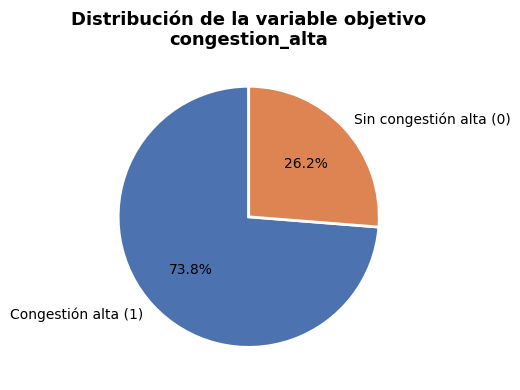

In [12]:
conteo_target = data['congestion_alta'].value_counts()

plt.figure(figsize=(6, 4))
plt.pie(
    conteo_target.values,
    labels=[ 'Congestión alta (1)','Sin congestión alta (0)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Distribución de la variable objetivo\ncongestion_alta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Del total de 720 registros, 531 corresponden a congestión alta y 189 a no congestión. Esto significa que el dataset está **desbalanceado**. El 73.75% de los casos son positivos. Este desbalance es importante tenerlo en cuenta a la hora de entrenar el modelo, ya que un clasificador que predijera siempre congestión alta acertaría el 73.75% de las veces sin aprender nada útil.

Otra variable que podría generar dudas es `indice_congestion`. Esta variable numérica continua podría usarse como variable objetivo si el problema fuera de **regresión**, es decir, si quisiéramos predecir el nivel exacto de congestión como un número.

Sin embargo, el problema está planteado como **clasificación binaria**: predecir si hay congestión alta o no. Por eso la variable objetivo es `congestion_alta` (0 o 1), no `indice_congestion`.

Es muy probable que `congestion_alta` se haya derivado directamente de `indice_congestion` aplicando un umbral fijo:

- congestion_alta = 1  si  indice_congestion > umbral X
- congestion_alta = 0  si  indice_congestion ≤ umbral X

Si esto es así, los registros con `congestion_alta = 0` deberían tener valores de `indice_congestion` siempre por debajo de ese umbral, y los de `congestion_alta = 1` siempre por encima. Vemos si esta afirmación es correcta:

In [13]:
data['indice_congestion'].describe()

count    720.000000
mean      61.268333
std       11.296092
min       23.900000
25%       54.075000
50%       61.850000
75%       68.525000
max       92.600000
Name: indice_congestion, dtype: float64

In [14]:
data.groupby('congestion_alta')['indice_congestion'].describe()

,count,mean,std,min,25%,50%,75%,max
congestion_alta,,,,,,,,
0,189.0,53.692593,9.994208,23.9,47.00,54.5,60.60,79.9
1,531.0,63.964783,10.484446,33.9,57.05,64.0,70.85,92.6


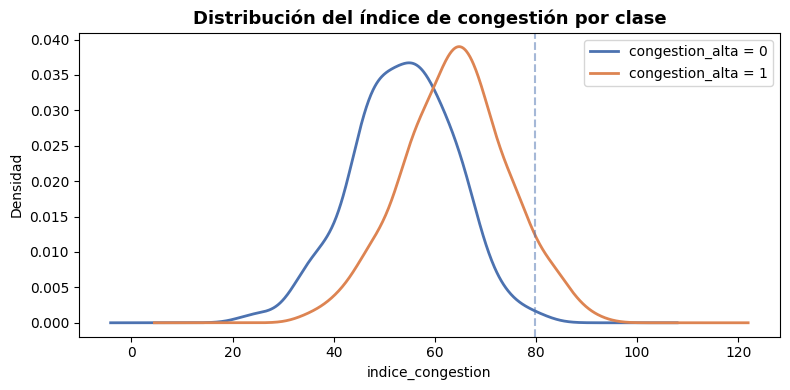

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = data[data['congestion_alta'] == label]['indice_congestion']
    subset.plot(kind='kde', ax=ax, label=f'congestion_alta = {label}', color=color, linewidth=2)

ax.set_title('Distribución del índice de congestión por clase', fontsize=13, fontweight='bold')
ax.set_xlabel('indice_congestion')
ax.set_ylabel('Densidad')
ax.legend()
ax.axvline(x=data[data['congestion_alta']==0]['indice_congestion'].max(), 
           color='#4C72B0', linestyle='--', alpha=0.5, label='Máx clase 0')
plt.tight_layout()
plt.show()

El gráfico de densidad muestra la distribución del índice de congestión separada por clase:

- La curva azul (congestion_alta = 0) se concentra alrededor de 54 puntos
- La curva naranja (congestion_alta = 1) se concentra alrededor de 64 puntos
- Las curvas **se solapan significativamente** —> no existe un umbral fijo que separe perfectamente ambas clases

Esto descarta la hipótesis de que `congestion_alta` se derive de aplicar un corte limpio sobre `indice_congestion`. La separación entre clases existe pero no es perfecta.

A pesar de esto, `indice_congestion` no debe usarse como variable predictora en el modelo por dos razones:

1. **Data leakage**: ambas variables miden el mismo fenómeno. Si en producción tuviéramos el índice de congestión disponible, ya sabríamos directamente si hay congestión alta o no, haciendo innecesario el modelo.
2. **El objetivo real del modelo** : es anticipar la congestión usando variables previas al evento, meteorología, aforo, franja horaria, incidencias, no variables que describen el propio evento.

Por tanto, `indice_congestion` se debe excluir del conjunto de variables predictoras.

### Act 1: Caso de uso

La primera actividad nos pide definir el problema antes de tocar los datos. Más allá de identificar la variable objetivo, el objetivo es responder a tres preguntas clave:

- **¿Qué predice el modelo?** — qué información concreta genera como salida
- **¿Quién usaría esa predicción?** — qué perfil de usuario o equipo tomaría decisiones a partir de ella
- **¿Qué decisiones operativas permitiría tomar?** — cómo se traduciría la predicción en acciones reales sobre la ciudad

Definir esto antes de entrenar cualquier modelo es fundamental. Sin entender quién va a usar la predicción y para qué, es imposible saber qué métrica optimizar, qué tipo de error es más costoso o si el modelo tiene sentido en producción.


| Elemento | Respuesta |
|---|---|
| **Variable objetivo** | `congestion_alta` — variable binaria que indica si hay congestión alta (1) o no (0) |
| **Qué predice el modelo** | La probabilidad de que se produzca un episodio de congestión alta en un distrito y franja horaria determinados, a partir de variables de movilidad, meteorología y contexto urbano |
| **Quién usaría la predicción** | El equipo de operaciones de movilidad urbana del Ayuntamiento — técnicos que monitorizan el tráfico en tiempo real y toman decisiones sobre la gestión de la ciudad |
| **Decisión operativa 1** | **Ajuste semafórico predictivo** — modificar los ciclos de semáforos en los accesos al distrito antes de que se forme el atasco para fluidificar la entrada de vehículos |
| **Decisión operativa 2** | **Aviso anticipado a ciudadanos** — lanzar notificaciones push en la app municipal avisando de congestión esperada para que los usuarios elijan rutas alternativas o transporte público |
| **Decisión operativa 3** | **Refuerzo de líneas de autobús** — activar autobuses extra en las líneas que atraviesan la zona antes de que se produzca el episodio |
| **Decisión operativa 4** | **Cierre preventivo de accesos** — cortar el acceso de vehículos privados a zonas con alta probabilidad de congestión y redirigirlos por vías alternativas |
| **Decisión operativa 5** | **Activación de agentes de tráfico** — desplegar agentes en los puntos críticos predichos antes de que la congestión se materialice, en lugar de enviarlos cuando ya es tarde |

## Comprensión del dataset

En esta sección se analiza el dataset antes de entrenar ningún modelo. El objetivo es identificar qué variables parecen útiles para predecir la congestión alta, cuáles podrían ser irrelevantes o introducir ruido, cuáles podrían causar sesgo y cuáles necesitan algún tipo de transformación antes de ser usadas. Como se indica en el enunciado, no es necesario acertar en todo desde el principio, pero sí justificar las hipótesis iniciales con lo que se observa en los datos.